

  <center><font size=9> <b>Movie Recommendation Using Word2Vec and Sentence Transformers</b></center></font>


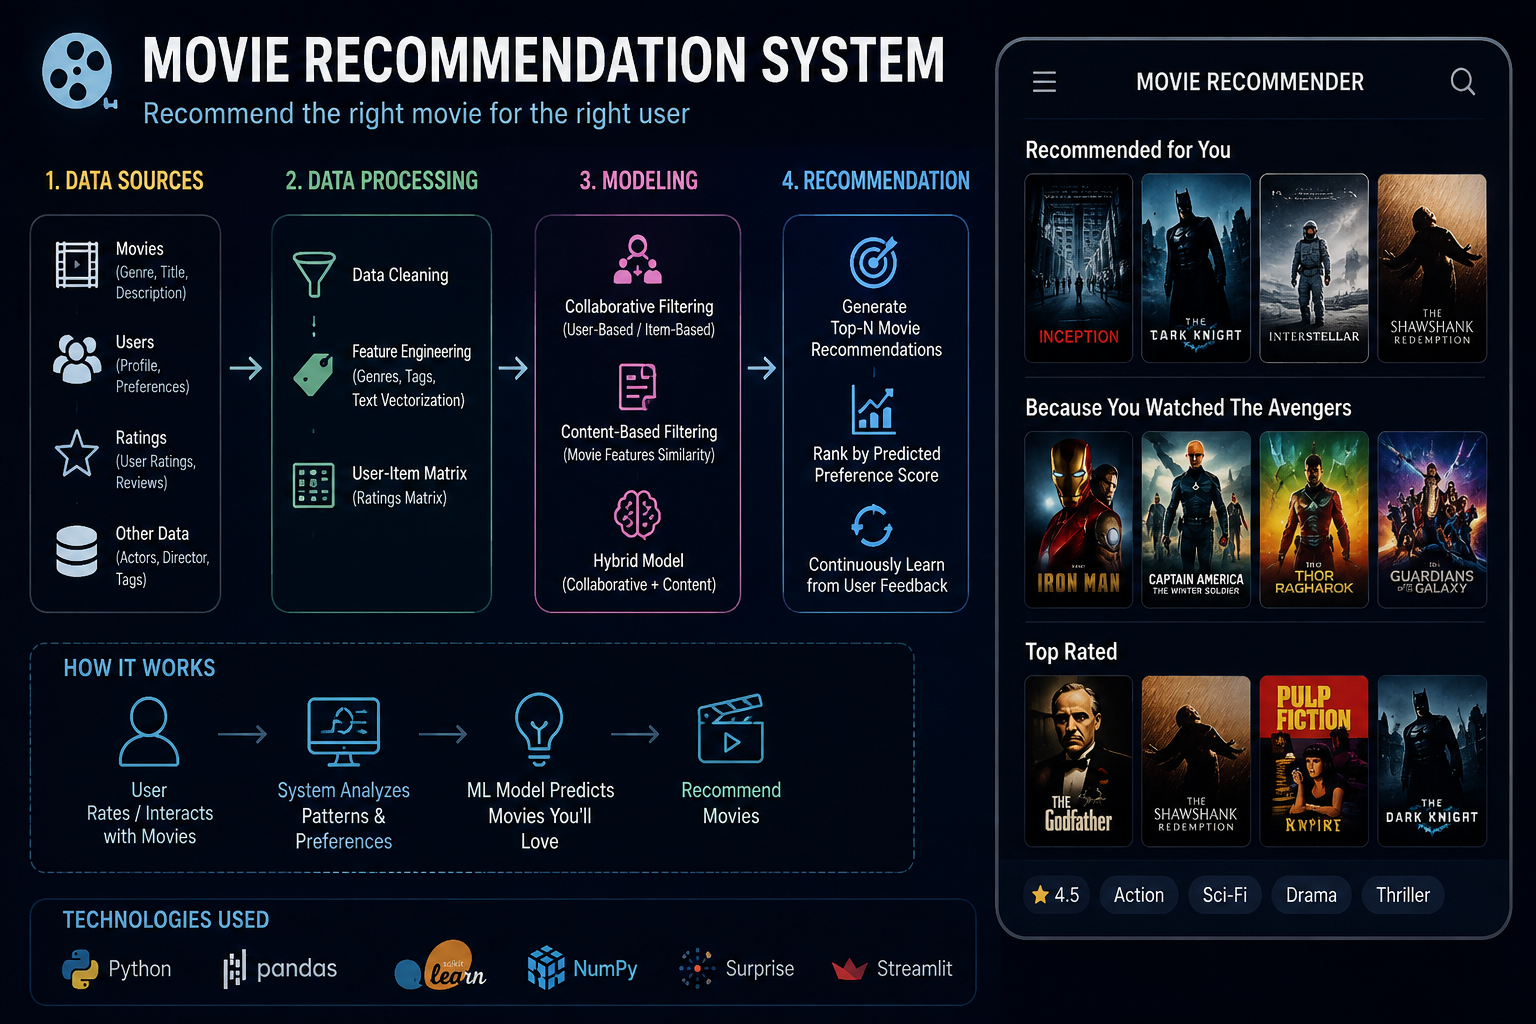

# **Problem Statement**

## **Business Context**






Streamora is a growing OTT platform that currently recommends movies based on titles, descriptions, and genres. However, many users ignore these recommendations and prefer to search for movies themselves, showing that the system may not understand their actual preferences. To improve this, Streamora should consider user behavior such as watch history, search history, likes, ratings, skips, and frequently watched genres. By using these preferences, Streamora can provide more personalized and relevant movie recommendations. This can improve user satisfaction, increase engagement and watch time, improve customer retention, and encourage users to watch more content.


##  **Objective**

Streamora’s current recommendation system does not fully match users’ interests, leading to low engagement with suggested movies. To improve this, the platform will analyze 11 months of historical viewing data, especially the sequence of movies watched by users. Using AI, Streamora aims to develop a personalized recommendation system that better understands user preferences and viewing behavior. This will help provide relevant movie suggestions, increase user engagement and content consumption, and improve customer loyalty.


## **Data Description**

**Movie Data**
- **title**: Name of the movie.
- **genres**: Genres of the movie, such as Action, Drama, Comedy, etc.
- **overview**: A short summary of the movie’s story or plot.

**Evaluation Data**
- **movie_1 to movie_7**: The user’s 7 most recently watched movies.
- **date:** The date when the recommendation or evaluation was recorded.
- **movie_watch:** The movie that the user actually watched after the recommendation.
- **past_success**: Indicates whether the previous recommendation was successful (True/False).

# **Importing Necessary Libraries**

In [ ]:
!pip install \
    numpy==1.26.4 \
    scikit-learn==1.6.1\
    scipy==1.13.1\
    gensim==4.3.3 \
    sentence-transformers==3.4.1 \
    gradio==5.33.0\
    pandas==2.2.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 63.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done


In [ ]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import random

# Set seeds for reproducibility
seed = 42
np.random.seed(seed)
random.seed(seed)

# **Loading the Data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
movie_data = pd.read_csv('/content/drive/MyDrive/Dataset/GenAIDataset/movie_dataset_title.csv')


In [ ]:
evaluation_data=pd.read_csv('/content/drive/MyDrive/Dataset/GenAIDataset/Evaluation_Data.csv')

# **Data Overview**

## **Movie Data**

In [ ]:
movie_data.shape

The dataset consists of 4803 rows and 3 columns

In [ ]:
movie_data.head(10)


In [ ]:
movie_data.info()


The dataset contains 4,803 movie records with 3 key features:

- title: Movie name — available for all entries.
- overview: Missing in 3 records.
- genres: Missing in 28 records.

In [ ]:
movie_data.dropna(inplace=True)

In [ ]:
movie_data.reset_index(drop=True, inplace=True)

## **Evaluation Data**

In [ ]:
evaluation_data.shape

The dataset consists of 2000 rows and 10 columns

In [ ]:
evaluation_data.head(10)

In [ ]:
evaluation_data.info()

## **Dataset Overview**

The dataset contains **2,000 rows** and **10 columns**.

### **Columns**

- **`movie_1` to `movie_7`**: Represent the user's 7 most recently watched movies. These columns have an **object** data type.
- **`movie_watch`**: Represents the movie currently watched by the user. It has an **object** data type.
- **`past_success`**: Indicates whether the previous recommendation was successful (**True/False**). It has a **boolean** data type.
- **`date`**: Represents the date information. It has an **object** data type.

### Data Quality
**bold text**
- **Total Rows:** 2,000
- **Missing Values:** None
- **Data Types:** Object and Boolean


There are **no missing values** in the dataset.


# **EDA**

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the 'date' column to datetime objects
# This is necessary to extract month and year information easily.
evaluation_data['date'] = pd.to_datetime(evaluation_data['date'])

# Extract month and year from the 'date' column
# We combine year and month to group data by calendar month across years.
evaluation_data['month_year'] = evaluation_data['date'].dt.to_period('M')

# Group by month and count the occurrences of each 'Past success' value
# This gives us the total count of True and False successes for each month.
monthly_success_counts = evaluation_data.groupby('month_year')['past_success'].value_counts().unstack(fill_value=0)

# Calculate the percentage of 'True' success for each month
# We divide the count of True successes by the total count (True + False) for that month and multiply by 100.
monthly_success_counts['Success Percentage'] = (monthly_success_counts[True] / (monthly_success_counts[True] + monthly_success_counts[False])) * 100

# Sort the data by month and year
# This ensures the plot displays the months in chronological order.
monthly_success_counts = monthly_success_counts.sort_index()

# Create the plot
# We use seaborn for a visually appealing bar plot.
plt.figure(figsize=(12, 6)) # Set the size of the figure for better readability
sns.barplot(x=monthly_success_counts.index.astype(str), y='Success Percentage', data=monthly_success_counts) # Create a bar plot with month_year on x-axis and Success Percentage on y-axis. Use a colormap 'viridis'.

# Add labels and title to the plot
plt.xlabel('Month-Year') # Label for the x-axis
plt.ylabel('Success Rate (%)') # Label for the y-axis
plt.title('Monthly Success Rate of Past Model Predictions') # Title of the plot
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability, especially if there are many months
plt.tight_layout() # Adjust layout to prevent labels from overlapping

# Display the plot
plt.show()

- April 2024: ~19.4%, the highest observed success rate.
- September 2024: ~10%, the lowest observed success rate.
- This represents roughly a 9.4 percentage-point decline between the reported high and low.

## **Observation**

- The success rate of past model recommendations varied between **10% and 19.4%** across the months.
- The **highest success rate** was observed in **April 2024 (~19.4%)**, indicating the best performance of the previous recommendation model.
- The **lowest success rate** was recorded in **September 2024 (~10%)**, indicating a significant drop in recommendation effectiveness.
- Overall, the results show that the previous recommendation model had **inconsistent performance** over time.

In [ ]:
# Calculate the overall success percentage
overall_success_percentage = (evaluation_data['past_success'].sum() / len(evaluation_data)) * 100

# Create a figure and an axes
fig, ax = plt.subplots(figsize=(6, 4))

# Create a bar plot for overall success
ax.bar(['Overall Success'], [overall_success_percentage], color='skyblue')

# Add the percentage value on top of the bar
ax.text('Overall Success', overall_success_percentage + 1, f'{overall_success_percentage:.2f}%', ha='center')

# Add labels and title
ax.set_ylabel('Success Rate (%)')
ax.set_title('Overall Success Rate of Past Model Predictions')
ax.set_ylim(0, 100) # Set y-axis limit to 0-100%

# Display the plot
plt.show()

**Observation**

- The past model achieved a 13.85% success rate in recommending movies that were actually watched.


# **Model Building**

## Embedding Approaches

In this project, we will experiment with **two different approaches** to generate vector representations of movie metadata:

### 1. Word2Vec-Based Model
- Learns **word-level embeddings** from tokenized movie metadata.
- Captures relationships between words based on their context.

### 2. Sentence Transformer-Based Model
- Generates **sentence-level embeddings** using pre-trained transformer models.
- Captures the **semantic meaning** of movie descriptions and metadata.

These embeddings will be used to calculate **movie-to-movie similarity** and build the recommendation system.



## **Word2Vec**

A Word2Vec-based movie recommendation system converts movie text into numerical vectors that capture meaning. The title, genres, and overview are combined and processed before training Word2Vec. Each movie gets one average embedding, and the system averages the embeddings of a user's recently watched movies. It then uses cosine similarity to find and recommend movies that are most similar to the user's viewing preferences.

**Word2Vec** is a technique that converts words into vector representations based on their contextual relationships in text. These word embeddings capture semantic meaning and can be averaged to represent longer pieces of text like movie descriptions.


**Process of Building a Word2Vec-Based Recommendation System**

1. **Text Preparation**
   Combine the relevant textual fields—**title**, **genres**, and **overview**—into a single string for each movie. Preprocess this combined text by tokenizing, lowercasing, and removing stopwords or punctuation to prepare it for model training.

2. **Model Training**
   Train a Word2Vec model on the preprocessed tokens. This model learns vector representations for each word based on their co-occurrence patterns in the corpus.

3. **Average Vector Calculation**
   Define a function to compute the average Word2Vec embedding for any given text. This is done by averaging the vectors of all valid tokens present in the trained vocabulary.

4. **Embedding Computation**
   For each movie, compute a **single embedding** by taking the average of the word vectors from the combined text (title + genres + overview).

5. **Generating Recommendations**
   To recommend movies:

   * Take the list of recently watched movies by a user.
   * Compute the average embedding of these movies using their content embeddings.
   * Calculate cosine similarity between this average vector and all other movie embeddings.
   * Return the top-ranked movies that are most similar to the user's recent viewing history.


### **Model Building**

#### <font size=4>**Step 1: Text Preperation**

Combines important text fields (like title, genre, and description) and cleans them by removing punctuation, stopwords, and converting everything to lowercase. This helps the model focus on the actual content.

In [ ]:
data_word2vec=movie_data.copy()

In [ ]:
from gensim.utils import simple_preprocess
data_word2vec['text'] = data_word2vec['title'] + ' ' + data_word2vec['genres'].replace('|', ' ', regex=True) + ' ' + data_word2vec['overview']
data_word2vec['tokens'] = data_word2vec['text'].apply(lambda x: simple_preprocess(x))

- apply() is used to apply a function to each row or column of a DataFrame, making data transformation easier without loops.
- lambda() creates a small, anonymous function for simple and quick operations.

####<font size=4>**Step 2: Model Training**

Trains the system to understand word meanings based on how often and where words appear together. This helps capture relationships between similar or related terms.

In [ ]:
model_word2vec = Word2Vec(sentences=data_word2vec['tokens'], vector_size=100, window=5, min_count=1, workers=4,seed=42)


A **pretrained Word2Vec model** may not understand domain-specific words and relationships well because it is trained on general text. Therefore, **training Word2Vec on your own domain data** can produce more accurate and relevant word embeddings for tasks like movie recommendations, medical analysis, or legal text.


- **sentences**: The tokenized text used to train Word2Vec.
- **vector_size=100**: Represents each word using a 100-dimensional vector.
- **window=5:** Considers 5 words before and after the target word as context.
- **min_count=1:** Includes all words, even those appearing only once.
- **workers=4:** Uses 4 CPU cores for faster training.
- **seed=42**: Ensures the results are reproducible.

#### <font size=4>**Step 3: Average Vector Calculation**

Averaging word embeddings combines the vectors of all words in a sentence to create a single vector that represents its overall semantic meaning. It also allows sentences of different lengths to be compared, as each sentence is represented by a vector of the same dimension.


In [ ]:
def get_avg_word_vector(tokens, model):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(model.vector_size)


#### <font size=4>**Step 4: Embedding Computation**

Converts each word into a fixed-length numerical vector that captures its meaning. These vectors help the system identify and compare similarities between different items.


In [ ]:
data_word2vec['embedded_vector'] = data_word2vec['tokens'].apply(lambda x: get_avg_word_vector(x, model_word2vec))


- It calculates the average word vector for each list of tokens using the Word2Vec model.


#### <font size=4>**Step 5: Generating Recommedations**


The average embedding of recently watched movies represents the user's overall taste. The system compares this with other movies using cosine similarity to find similar content. Movies that the user has already watched are removed to provide fresh and relevant recommendations.


In [ ]:
def word2vec_recommendations(recently_watched_titles, data, model, n_recommendations=10):

    # Get embeddings for the recently watched movies
    watched_embeddings = []
    for title in recently_watched_titles:
        movie_row = data[data['title'] == title]
        if not movie_row.empty:
            watched_embeddings.append(movie_row.iloc[0]['embedded_vector'])

    if not watched_embeddings:
        return ["Could not find embeddings for recently watched movies."]

    # Compute the average embedding of the recently watched movies
    avg_watched_embedding = np.mean(watched_embeddings, axis=0)

    # Calculate cosine similarity between the average watched embedding and all movie embeddings
    all_embeddings = np.vstack(data['embedded_vector'].values)
    similarities = cosine_similarity([avg_watched_embedding], all_embeddings)[0]

    # Get the indices of the top n most similar movies
    # Exclude movies that were recently watched
    recommended_indices = similarities.argsort()[::-1] # Sort in descending order

    recommended_titles = []
    for idx in recommended_indices:
        movie_title = data.iloc[idx]['title']
        if movie_title not in recently_watched_titles:
            recommended_titles.append(movie_title)
            if len(recommended_titles) >= n_recommendations:
                break

    return recommended_titles

Let's generate recommendations from the movies we've already watched.

In [ ]:
watched_movies = ['The Avengers', 'Iron Man', 'Man of Steel']
word2vec_recommendations(watched_movies, data_word2vec, model_word2vec)


The Word2Vec model gave mixed results. Some movies, such as *Live Free or Die Hard*, *Oblivion*, and *Species*, were related through action and sci-fi elements. However, movies like *When a Stranger Calls*, *The Good Guy*, and *Creepshow 2* were less relevant to the original superhero movies, showing that the Word2Vec recommendations had limited accuracy.


### **Evaluation**

In [ ]:
past_movies = evaluation_data[['movie_1', 'movie_2', 'movie_3', 'movie_4', 'movie_5', 'movie_6', 'movie_7']].values.tolist()

In [ ]:
word2vec_recommendations_list = []
for watched_movies_list in past_movies:
    # Filter out None values from the watched_movies_list
    valid_watched_movies = [movie for movie in watched_movies_list if movie is not None]
    recommendations = word2vec_recommendations(valid_watched_movies, data_word2vec, model_word2vec, n_recommendations=10)
    word2vec_recommendations_list.append(recommendations)

# Print the first few recommendations from the word2vec model
print("Word2Vec Recommendations for the first row:", word2vec_recommendations_list[0])

In [ ]:
evaluation_data['word2vec_match'] = evaluation_data.apply(lambda row: row['movie_watch'] in word2vec_recommendations_list[row.name], axis=1)

result_df = evaluation_data[['date', 'movie_watch', 'word2vec_match']]
result_df

In [ ]:
# Calculate the overall success percentage for Word2Vec
overall_word2vec_success_percentage = (evaluation_data['word2vec_match'].sum() / len(evaluation_data)) * 100

# Create a figure and an axes
fig, ax = plt.subplots(figsize=(6, 4))

# Create a bar plot for overall success
ax.bar(['Overall Word2Vec Success'], [overall_word2vec_success_percentage], color='lightgreen')

# Add the percentage value on top of the bar
ax.text('Overall Word2Vec Success', overall_word2vec_success_percentage + 1, f'{overall_word2vec_success_percentage:.2f}%', ha='center')

# Add labels and title
ax.set_ylabel('Success Rate (%)')
ax.set_title('Overall Success Rate of Word2Vec Model Recommendations')
ax.set_ylim(0, 100) # Set y-axis limit to 0-100%

# Display the plot
plt.show()

**Observation:**
- The Word2Vec model achieves an average recommendation success rate of 22.7%.


 - Monthly success is the percentage of movies watched by users that were included in the model's recommendation list. It shows how well the recommendations match the user's actual choices.


In [ ]:
import matplotlib.pyplot as plt

# Convert 'date' column to datetime objects
result_df['date'] = pd.to_datetime(result_df['date'])

# Extract month and year
result_df['month_year'] = result_df['date'].dt.to_period('M')

# Group by month and count total watches and matches
monthly_summary = result_df.groupby('month_year').agg(
    total_watches=('movie_watch', 'count'),
    successful_recommendations=('word2vec_match', lambda x: (x == True).sum())
).reset_index()

# Calculate success rate
monthly_summary['success_rate'] = (monthly_summary['successful_recommendations'] / monthly_summary['total_watches']) * 100

# Sort by month and year
monthly_summary = monthly_summary.sort_values(by='month_year')

# Convert month_year to string for plotting
monthly_summary['month_year_str'] = monthly_summary['month_year'].astype(str)

# Create the bar chart
plt.figure(figsize=(12, 6))
plt.bar(monthly_summary['month_year_str'], monthly_summary['success_rate'], color='skyblue')
plt.xlabel('Month')
plt.ylabel('Success Rate (%)')
plt.title('Monthly Recommendation Success Rate (Word2Vec)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **Observation**

* The **success rate is between 17% and 27%**, showing moderate performance of the Word2Vec recommendation system.
* The **highest success rate** was in **February 2024**, at around **27%**.
* The **lowest success rate** was in **September and November 2024**, at around **16–17%**.


## **Sentence Transformer**

### **Sentence Transformers**

Sentence Transformers are models that convert sentences or text into numerical vectors called **embeddings**. These embeddings capture the meaning of the text and help the system find similar movies.

### **Process of Building a Sentence Transformer-Based Recommendation System**

1. **Creating a Separate Embedding DataFrame**

   Create a new DataFrame called `data_sentf` to store the movie embeddings separately without changing the original movie data.

2. **Loading the Model**

   Load a pre-trained Sentence Transformer model such as `all-MiniLM-L6-v2`. This model is efficient and works well for finding similarities between text.

3. **Generating Movie Embeddings**

   Generate embeddings separately for the **title, genres, and overview** of each movie. Combine these embeddings to create one representation for each movie and store them in `data_sentf`.

4. **Generating Recommendations**

   * Take the movies recently watched by the user.
   * Calculate the average embedding of these movies.
   * Compare this average embedding with other movies using **cosine similarity**.
   * Select the most similar movies.
   * Return the **top recommended movies**.


### **Model Building**

#### <font size=4>**Step 1: Creating a Separate Embedding DataFrame**

In [ ]:
data_sentf=movie_data.copy()

#### <font size=4>**Step 2: Model Loading**

Using a pre-trained SentenceTransformer model allows us to leverage powerful language understanding without the need to train from scratch. Models like 'all-MiniLM-L6-v2' are optimized for capturing semantic similarity efficiently.

In [ ]:
model_sentf = SentenceTransformer('all-MiniLM-L6-v2')

#### <font size=4>**Step 3: Generating and Storing Combined Embeddings**

Creating embeddings for the **title, genres, and overview** helps the model understand different parts of the movie. Combining these embeddings gives a complete representation of the movie. Storing the combined embeddings also makes the recommendation process faster by avoiding repeated calculations.


In [ ]:

def get_combined_embedding(title, genres, overview, model):
    # Create a combined string
    combined_text = f"{title} {genres} {overview}"
    # Generate embedding for the combined text
    embedding = model.encode(combined_text)
    return embedding

# Apply the function to create embeddings for all movies
data_sentf['embedded_vector'] = data_sentf.apply(
    lambda row: get_combined_embedding(row['title'], row['genres'], row['overview'], model_sentf), axis=1
)

#### <font size=4>**Step 4: Generating Recommendations**

Using the average embedding of recently watched movies helps understand the user's overall taste. The system compares it with other movies using **cosine similarity** to find similar content. Movies that the user has already watched are removed so that the recommendations are **new and relevant**.


In [ ]:
def recommend_movies_sentf(watched_movies_titles, data, model, n=10):

    watched_movies_embeddings = []
    for title in watched_movies_titles:
        movie = data[data['title'] == title]
        if not movie.empty:
            # Use 'combined_embedding' column here
            watched_movies_embeddings.append(movie.iloc[0]['embedded_vector'])


    if not watched_movies_embeddings:
        return []

    # Calculate the average embedding of watched movies
    avg_embedding = np.mean(watched_movies_embeddings, axis=0)

    # Calculate cosine similarity with all other movies using 'combined_embedding'
    similarities = cosine_similarity([avg_embedding], np.vstack(data['embedded_vector'].values))

    # Get the indices of the most similar movies (excluding the watched ones)
    similar_indices = similarities.argsort()[0][::-1]

    recommended_movies = []
    for index in similar_indices:
        movie_title = data.iloc[index]['title']
        if movie_title not in watched_movies_titles:
            recommended_movies.append(movie_title)
        if len(recommended_movies) == n:
            break

    return recommended_movies


In [ ]:
last_three = ['The Avengers', 'Iron Man', 'Man of Steel']
res=recommend_movies_sentf(last_three,data_sentf,model_sentf,10)
res

Sentence Transformer model delivered strong, relevant recommendations. Titles like *Iron Man 2*, *Avengers: Age of Ultron*, *Captain America: Civil War*, and *Thor* are directly connected to the original superhero universe or share similar themes of action, heroism, and world-building. These suggestions show a much better understanding of genre and viewer intent.

### **Evaluation**

In [ ]:

sentf_recommendations = []
for watched_movies_list in past_movies:
    # Filter out None values from the watched_movies_list
    valid_watched_movies = [movie for movie in watched_movies_list if movie is not None]
    recommendations = recommend_movies_sentf(valid_watched_movies, data_sentf, model_sentf, n=10)
    sentf_recommendations.append(recommendations)

# Print the first few recommendations from the sentence transformer model
print("Sentence Transformer Recommendations for the first row:", sentf_recommendations[0])

In [ ]:

evaluation_data['sentf_match'] = evaluation_data.apply(
    lambda row: row['movie_watch'] in sentf_recommendations[row.name], axis=1
)

result_df = evaluation_data[['date', 'movie_watch', 'sentf_match']]
result_df


In [ ]:

# Calculate the overall success percentage for the Sentence Transformer model
overall_success_percentage_sentf = (evaluation_data['sentf_match'].sum() / len(evaluation_data)) * 100

# Create a figure and an axes
fig, ax = plt.subplots(figsize=(6, 4))

# Create a bar plot for overall success
ax.bar(['Overall Success (Sentence Transformer)'], [overall_success_percentage_sentf], color='lightgreen')

# Add the percentage value on top of the bar
ax.text('Overall Success (Sentence Transformer)', overall_success_percentage_sentf + 1, f'{overall_success_percentage_sentf:.2f}%', ha='center')

# Add labels and title
ax.set_ylabel('Success Rate (%)')
ax.set_title('Overall Success Rate of Sentence Transformer Model Predictions')
ax.set_ylim(0, 100) # Set y-axis limit to 0-100%

# Display the plot
plt.show()


**Observation:**
- The Sentence Transformer model achieves an average recommendation success rate of 64.75%.


In [ ]:
# Convert 'date' column to datetime objects
result_df['date'] = pd.to_datetime(result_df['date'])

# Extract month and year
result_df['month_year'] = result_df['date'].dt.to_period('M')

# Group by month and count total watches and matches
monthly_summary_sentf = result_df.groupby('month_year').agg(
    total_watches=('movie_watch', 'count'),
    successful_recommendations=('sentf_match', lambda x: (x == True).sum())
).reset_index()

# Calculate success rate
monthly_summary_sentf['success_rate'] = (monthly_summary_sentf['successful_recommendations'] / monthly_summary_sentf['total_watches']) * 100

# Sort by month and year
monthly_summary_sentf = monthly_summary_sentf.sort_values(by='month_year')

# Convert month_year to string for plotting
monthly_summary_sentf['month_year_str'] = monthly_summary_sentf['month_year'].astype(str)

# Create the bar chart
plt.figure(figsize=(12, 6))
plt.bar(monthly_summary_sentf['month_year_str'], monthly_summary_sentf['success_rate'], color='lightcoral')
plt.xlabel('Month')
plt.ylabel('Success Rate (%)')
plt.title('Monthly Recommendation Success Rate (Sentence Transformer)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### **Observation**

* The success rate is between **62% and 68%**, showing **strong and consistent performance**.
* The higher performance is mainly because **Sentence Transformers understand the context and meaning of complete sentences**, while Word2Vec works at the individual word level.
* The **highest success rate** is seen in **March and August 2024**, at around **67–68%**.
* The **lowest success rate** is seen in **October 2024**, at around **63%**.
* Most months have a success rate above **64%**, showing that the model provides **good and consistent recommendations**.


# **Model Comparison**

The Sentence Transformer model significantly **outperforms** both:

* The **Word2Vec-based model** (which ranged between \~17% to 27%)
* The **Past recommendation model** (which had lower success percentages overall of ~13.5%)

This demonstrates that **contextually-rich sentence embeddings from transformers** provide a more accurate and reliable basis for generating recommendations.

# **Conclusion**

* A **movie recommendation system** was developed using **Word2Vec and Sentence Transformers** to provide personalized movie recommendations.
* The **Sentence Transformer model performed better** because it understands the context and meaning of movie information more effectively.
* In the future, the system can be improved by using **more user behavior data, additional movie information, and fine-tuning the Transformer model**.
